# Giai đoạn 9 — Tinh chỉnh mô hình

```
┌───────────────────────────────────────────────────────────────────────┐
│                              09_TinhChinh                             │
└───────────────────────────────────────────────────────────────────────┘

  ĐẦU VÀO
    • 06_GA_TangCuong/  —  dữ liệu tăng cường RIÊNG theo từng fold
    • 03_TachTrainTest/ —  574 dòng thật + 15 fold
    • 04_MocChuan/moc_chuan.json  —  mốc M₀ phải vượt
         │
         ▼
  XỬ LÝ
    1. Đo: thêm 2.613 dòng tăng cường có giúp gì không?
    2. Quét siêu tham số, loại cấu hình nhớ vẹt quá mức
    3. Dò trọng số dòng thật
    4. Thử PHÂN TẦNG cho khối nhiều ngành — đoán lĩnh vực con trước
    5. Xác nhận cấu hình thắng trên đủ 15 fold
         │
         ▼
  ĐẦU RA
    • 09_TinhChinh/sieu_tham_so.json  —  cấu hình chốt cho Giai đoạn 10
    • 09_TinhChinh/ket_qua_quet.csv
    • 09_TinhChinh/hinh_9_*.png       —  3 hình
```

## Vì sao dữ liệu tăng cường phải lấy RIÊNG theo fold

`train_final.csv` dùng bản sinh từ phân phối học trên **toàn bộ 574 dòng train** — đúng cho mô hình
cuối ở Giai đoạn 10, nhưng **sai cho cross-validation**: phần validation của mỗi fold đã gián tiếp
góp phần tạo ra dữ liệu huấn luyện.

Chênh lệch không nhỏ: dùng nhầm bản đó thì Top-3 đo được là **79,8%**, dùng đúng bản theo fold thì
**69,3%**. Gần 10 điểm hoàn toàn là rò rỉ.

## Mục tiêu KÉP

Thầy yêu cầu *"80–90% cả train lẫn test"*. Giai đoạn 4 cho thấy mô hình đạt **100% trên train** mà
chỉ 67,4% trên validation. Con số 100% không phải thành tích — nó là **nhớ vẹt**: cây quyết định chẻ
nhỏ tới khi mỗi phiếu nằm riêng một nhánh, việc quá dễ với XGBoost.

Ý chính trong lời thầy là **hai cột phải gần nhau**. Nên giai đoạn này tối ưu đồng thời:

1. tối đa Top-3 trên validation
2. ép chênh train − validation xuống

## Phân tầng — học hai bước cho khối nhiều ngành

Khối *Kinh doanh & Quản lý* có 10 ngành. Học một lượt 10 lớp bắt mô hình vẽ đồng thời **45 đường
ranh giới**, kể cả những cặp gần như không tách được (Marketing vs Kinh doanh quốc tế). Sức của mô
hình bị dàn mỏng.

Học hai bước thì bước đầu chỉ phải tách vài lĩnh vực con — việc **dễ hơn và có tín hiệu thật**:

```
bước 1:  Tài chính–Kế toán  |  Marketing–Kinh doanh  |  Vận hành–Chuỗi cung ứng
bước 2:  trong lĩnh vực đó, ngành nào?

P(ngành) = P(lĩnh vực con) × P(ngành | lĩnh vực con)
```

**Đây KHÔNG phải thu hẹp bài toán.** Mô hình tự đoán lĩnh vực con, người dùng không cung cấp gì
thêm, đầu ra vẫn là xác suất trên đủ 10 ngành. Kiểm chứng được: **mốc đoán bừa vẫn là 30%** trong cả
hai cách. Nếu là thu hẹp thì mốc đó đã phải tăng.


In [1]:
import json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, Rectangle

warnings.filterwarnings("ignore")

PROC = Path("../data/processed")
RAW  = Path("../data/raw")
SEED = 42
np.random.seed(SEED)

# Web gửi limit=3 (web/src/app/(main)/predict/page.tsx) nên Top-3 là chỉ tiêu
# chính; Top-1/2/5 báo cáo kèm để thấy toàn cảnh.
TOP_K = (1, 2, 3, 5)

# Thư mục đầu ra trùng khít tên notebook
GIAI_DOAN = {
    1: "01_LamSachKhaoSat",
    2: "02_ChuanBiTTTH",
    3: "03_TachTrainTest",
    4: "04_MocChuan",
    5: "05_HocPhanPhoi",
    6: "06_GA_TangCuong",
    7: "07_KiemDinhGA",
    8: "08_TrainFinal",
    9: "09_TinhChinh",
    10: "10_ChotModel",
}


def thu_muc(i):
    """Thư mục đầu ra của giai đoạn i, tạo sẵn nếu chưa có."""
    p = PROC / GIAI_DOAN[i]
    p.mkdir(parents=True, exist_ok=True)
    return p


# ── Kiểu biểu đồ thống nhất cho toàn bộ báo cáo ──────────────────────────────
plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 220, "savefig.bbox": "tight",
    "font.family": "DejaVu Sans", "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlepad": 14,
    "axes.labelsize": 11, "axes.labelpad": 8,
    "axes.grid": True, "grid.alpha": 0.18, "grid.linestyle": "-", "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.spines.left": False, "axes.edgecolor": "#B0B7BF",
    "figure.facecolor": "white", "axes.facecolor": "white",
    "legend.frameon": False, "legend.fontsize": 10,
    "xtick.labelsize": 10, "ytick.labelsize": 10,
    "xtick.color": "#4A5560", "ytick.color": "#4A5560",
    "axes.labelcolor": "#2C3E50", "text.color": "#2C3E50",
})

C_THAT = "#D64550"   # dữ liệu thật
C_GA   = "#2BA84A"   # dữ liệu tổng hợp (GA)
C_XANH = "#3B7DD8"   # nhấn mạnh chính
C_CAM  = "#E8873A"   # nhấn mạnh phụ
C_TIM  = "#8E5FBF"
C_XAM  = "#AEB6BF"   # nền / mốc so sánh
C_DAM  = "#2C3E50"
C_NHOM = plt.get_cmap("tab20")(np.linspace(0, 1, 20))


def nhan_ngang(ax, gia_tri, fmt="{:,.0f}", lui=0.012, fs=10, mau=None):
    """Ghi số ở cuối mỗi thanh ngang."""
    lim = ax.get_xlim()[1]
    for i, v in enumerate(gia_tri):
        ax.text(v + lim * lui, i, fmt.format(v), va="center", fontsize=fs,
                fontweight="bold", color=mau or C_DAM)


def nhan_doc(ax, fmt="{:,.0f}", lui=0.02, fs=10):
    """Ghi số trên đầu mỗi cột dọc."""
    lim = ax.get_ylim()[1]
    for p in ax.patches:
        h = p.get_height()
        if h and abs(h) > 1e-9:
            ax.text(p.get_x() + p.get_width() / 2, h + lim * lui, fmt.format(h),
                    ha="center", va="bottom", fontsize=fs, fontweight="bold", color=C_DAM)


def chu_thich(fig, text, y=None):
    """Dòng chú giải dưới hình — nêu KẾT LUẬN rút ra, không mô tả lại hình.

    Chú giải (legend) đặt ngoài trục bằng bbox_to_anchor y âm có thể thò xuống
    dưới đáy hình; khi đó phải hạ dòng chú thích xuống dưới nó, nếu không hai bên
    đè lên nhau (bbox_inches="tight" nới khung chứ không dời chữ ra).
    """
    if y is None:
        y = -0.02
        fig.canvas.draw()
        r = fig.canvas.get_renderer()
        hop_ds = [lg.get_window_extent(r) for lg in fig.legends]
        hop_ds += [ax.get_legend().get_window_extent(r)
                   for ax in fig.axes if ax.get_legend() is not None]
        for hop in hop_ds:
            day = hop.transformed(fig.transFigure.inverted()).y0
            if day < y:
                y = day - 0.035
    fig.text(0.5, y, text, ha="center", va="top", fontsize=10.5,
             color="#5A6672", style="italic", wrap=True)


def ngat_dong(s, n=18):
    """Ngắt chuỗi dài thành nhiều dòng thay vì cắt cụt — nhãn vẫn đọc được hết."""
    tu, dong, cur = str(s).split(), [], ""
    for t in tu:
        if len(cur) + len(t) + 1 <= n or not cur:
            cur = f"{cur} {t}".strip()
        else:
            dong.append(cur); cur = t
    if cur:
        dong.append(cur)
    return "\n".join(dong)


def cho_chu_giai(ax, ngang=True, phan=0.28):
    """Nới trục để CHỪA CHỖ cho chú giải, tránh nó đè lên cột.

    Chú giải đặt trong vùng vẽ luôn có nguy cơ chồng lên dữ liệu. Cách chắc ăn
    là nới giới hạn trục thêm `phan` rồi đặt chú giải vào khoảng trống đó.
    """
    if ngang:
        lo, hi = ax.get_xlim(); ax.set_xlim(lo, hi + (hi - lo) * phan)
    else:
        lo, hi = ax.get_ylim(); ax.set_ylim(lo, hi + (hi - lo) * phan)


def cao_theo_dong(n, moi_dong=0.26, toi_thieu=4.5, toi_da=13):
    """Chiều cao hình cho biểu đồ cột ngang — 39 nhãn cần ~11 inch, không phải 7."""
    return float(np.clip(n * moi_dong + 2.0, toi_thieu, toi_da))


def luu(fig, ra, ten, chu=None):
    if chu:
        chu_thich(fig, chu)
    fig.savefig(ra / ten, dpi=220, bbox_inches="tight", facecolor="white")
    print(f"   💾 {ten}")


def tom_tat(tieu_de, dong_ds, rong=76):
    """Bảng tóm tắt cuối notebook — mỗi giai đoạn kết thúc bằng một cái."""
    print("╔" + "═" * rong + "╗")
    print("║" + f" {tieu_de} ".center(rong) + "║")
    print("╠" + "═" * rong + "╣")
    for d in dong_ds:
        print("║ " + str(d)[: rong - 2].ljust(rong - 1) + "║")
    print("╚" + "═" * rong + "╝")

def nap(co_test=False, co_ttth=True):
    """Đọc mọi thứ notebook huấn luyện cần.

    `co_test=True` CHỈ được bật ở Giai đoạn 10 — mở tập test đúng một lần.

    Khoá "nhom" đọc từ `nganh_to_nhom` trong mapping.json. Đây là ĐIỂM KHÁC BIỆT
    DUY NHẤT giữa research2 (7 khối HUIT) và research3 (10 nhóm nghề) — nhờ vậy
    hai nhánh là thí nghiệm có đối chứng thật sự.
    """
    m = json.loads((thu_muc(1) / "mapping.json").read_text(encoding="utf-8"))
    d = {
        "likert": m["cot_likert"],
        "diem": m["cot_diem"],
        "ma_to_ten": {int(k): v for k, v in m["ma_to_ten"].items()},
        "nhom": {int(k): v for k, v in m["nganh_to_nhom"].items()},
        "ten_nhom": {int(k): v for k, v in m["ten_nhom"].items()},
        "ten_cach_nhom": m.get("ten_cach_nhom", "nhóm ngành"),
        "train": pd.read_csv(thu_muc(3) / "khaosat_train.csv"),
        "folds": json.loads((thu_muc(3) / "cv_folds.json").read_text(encoding="utf-8")),
    }
    d["ttth"] = pd.read_csv(thu_muc(2) / "ttth_sach.csv") if co_ttth else pd.DataFrame()
    if co_test:
        d["test"] = pd.read_csv(thu_muc(3) / "khaosat_test_KHOA.csv")

    nguon = [d["train"].to_hop_thi.str.split(" ").str[0]]
    if co_ttth:
        nguon.append(d["ttth"].to_hop_thi.astype(str))
    d["to_hop"] = sorted(set().union(*[set(s) for s in nguon]))
    d["nganh"] = np.sort(d["train"].ma_nganh.unique())
    d["i_nganh"] = {m_: i for i, m_ in enumerate(d["nganh"])}

    # Thống kê điểm để quy z-score. Tính trên TRAIN (+ TTTH nếu dùng), tuyệt đối
    # không đụng test — nếu không thì thông tin test rò rỉ qua bước chuẩn hoá.
    goc = [d["train"][d["diem"]]] + ([d["ttth"][d["diem"]]] if co_ttth else [])
    g = pd.concat(goc).astype(float)
    d["diem_mu"] = g.mean().values
    d["diem_sd"] = g.std().replace(0, 1).values
    return d


def dac_trung(df, D, co_khao_sat=True):
    """Ma trận 63 đặc trưng — MỘT định nghĩa duy nhất cho cả hai nguồn dữ liệu.

    `co_khao_sat=False` dùng cho hồ sơ trúng tuyển: nguồn này chỉ có điểm thi và
    tổ hợp. Cột thiếu để NaN chứ không điền bừa — XGBoost học luôn hướng rẽ cho
    giá trị thiếu ngay trong thuật toán, còn điền bừa tạo ra giá trị không có thật.
    """
    n = len(df)
    L, C_DIEM = D["likert"], D["diem"]
    th = df["to_hop_thi"].astype(str).str.split(" ").str[0].values
    Dm = df[C_DIEM].astype(float).values
    Lk = df[L].astype(float).values if co_khao_sat else np.full((n, len(L)), np.nan)

    ph = [pd.DataFrame(Lk, columns=L)]

    # Likert chuẩn hoá theo từng người: người hay chọn 4-5 và người hay chọn 2-3
    # cùng "thích logic nhất" nhưng để thô thì mô hình đọc thành hai hồ sơ khác
    # hẳn. Trừ trung bình của chính người đó thì còn lại sở thích TƯƠNG ĐỐI.
    with np.errstate(invalid="ignore"):
        mu = np.nanmean(Lk, 1, keepdims=True)
        sd = np.nanstd(Lk, 1, keepdims=True)
    sd = np.where((sd == 0) | np.isnan(sd), 1.0, sd)
    ph.append(pd.DataFrame(Lk - mu, columns=[f"ips_{c}" for c in L]))
    ph.append(pd.DataFrame({"likert_tb": mu[:, 0], "likert_dolech": sd[:, 0]}))

    ph.append(pd.DataFrame(Dm, columns=C_DIEM))
    # 8.0 môn Toán và 8.0 môn Văn không cùng ý nghĩa — quy z-score mới so được
    z = (Dm - D["diem_mu"]) / D["diem_sd"]
    ph.append(pd.DataFrame(z, columns=[f"z_{c}" for c in C_DIEM]))
    with np.errstate(invalid="ignore", divide="ignore"):
        ph.append(pd.DataFrame({
            "diem_tb": np.nanmean(Dm, 1),
            "diem_lech": np.nanmax(Dm, 1) - np.nanmin(Dm, 1),
            "z_tb": np.nanmean(z, 1),
            "z_max": np.nanmax(z, 1),
        }))

    # Tổ hợp là dữ liệu phân loại, KHÔNG có thứ tự. Mã hoá thành số (A00=0,
    # A01=1…) sẽ dạy mô hình rằng D01 "lớn hơn" A00 và trung bình A00 với B00 ra
    # A01 — vô nghĩa. One-hot tránh được: mỗi cột chỉ hỏi "có thi tổ hợp này không".
    ph.append(pd.DataFrame({f"th_{t}": (th == t).astype(float) for t in D["to_hop"]}))
    gt = ((df["gioi_tinh"] == "Nam").astype(float).values if "gioi_tinh" in df
          else np.full(n, np.nan))
    mt = (df["muc_tieu_ma"].astype(float).values if "muc_tieu_ma" in df
          else np.full(n, np.nan))
    ph.append(pd.DataFrame({"gioi_tinh_nam": gt, "muc_tieu": mt}))
    return pd.concat([p.reset_index(drop=True) for p in ph], axis=1)


def nhom_dac_trung(cols, D):
    """Gom tên cột thành 8 nhóm — dùng khi in bảng thống kê và vẽ hình."""
    L, C_DIEM = D["likert"], D["diem"]
    return {
        "Likert thô": [c for c in cols if c in L],
        "Likert chuẩn hoá theo người": [c for c in cols if c.startswith("ips_")],
        "Thống kê Likert": [c for c in cols if c in ("likert_tb", "likert_dolech")],
        "Điểm thi thô": [c for c in cols if c in C_DIEM],
        "Điểm z-score từng môn": [c for c in cols if c.startswith("z_diem_")],
        "Phái sinh từ điểm": [c for c in cols
                              if c in ("diem_tb", "diem_lech", "z_tb", "z_max")],
        "Tổ hợp xét tuyển (one-hot)": [c for c in cols if c.startswith("th_")],
        "Nhân khẩu học & mục tiêu": [c for c in cols
                                     if c in ("gioi_tinh_nam", "muc_tieu")],
    }

from xgboost import XGBClassifier


def mo_hinh(**kw):
    """XGBoost phân loại. KHÔNG ép `objective` — với nhóm 2 ngành XGBoost tự
    dùng binary:logistic (không có num_class), ép multi:softprob sẽ lỗi."""
    return XGBClassifier(**{**dict(
        max_depth=5, n_estimators=400, learning_rate=0.06, min_child_weight=3,
        subsample=0.8, colsample_bytree=0.6, reg_lambda=5.0,
        tree_method="hist", n_jobs=-1, verbosity=0, random_state=SEED), **kw})


class MoHinhNganh:
    """Mô hình gợi ý ngành. Chỉ dùng XGBoost phân loại — không có gì khác.

    Cách hoạt động, một câu:
        mô hình cho ra XÁC SUẤT cho từng ngành → bỏ những ngành không thuộc
        nhóm người dùng chọn → lấy k ngành xác suất cao nhất còn lại.

    Hai chế độ, đúng cách web gọi API:
        fieldId = None  → xếp hạng cả 39 ngành          (chế độ khám phá)
        fieldId = k     → chỉ xếp hạng ngành trong nhóm k (chế độ tư vấn)

    `rieng_nhom=True` → mỗi nhóm một mô hình nhỏ, chỉ học các ngành của nhóm đó.
    Mô hình chung phải trải sức phân biệt mọi cặp ngành, kể cả cặp ở hai nhóm
    khác hẳn nhau mà thực tế không bao giờ phải so; mô hình riêng chỉ học đúng
    việc phân biệt vài ngành trong một nhóm.
    """

    def __init__(self, D, hp=None, rieng_nhom=False, hp_nhom=None,
                 phan_tang=None):
        """`phan_tang` — dict {mã nhóm: {mã ngành: id lĩnh vực con}}.

        Với nhóm nhiều ngành, học MỘT LƯỢT 10 lớp bắt mô hình vẽ đồng thời 45
        đường ranh giới, kể cả những cặp gần như không tách được. Học hai bước
        thì bước 1 chỉ phải tách vài lĩnh vực con — việc dễ hơn và có tín hiệu
        thật — rồi bước 2 mới đi vào chỗ khó:

            P(ngành) = P(lĩnh vực con) × P(ngành | lĩnh vực con)

        Mô hình TỰ đoán lĩnh vực con, người dùng không cung cấp gì thêm, nên mốc
        đoán bừa không đổi. Đo trên khối Kinh doanh (10 ngành): 44.5% → 49.3%.
        """
        self.D = D
        self.hp = hp or {}
        self.rieng_nhom = rieng_nhom
        self.hp_nhom = hp_nhom or {}
        self.phan_tang = phan_tang or {}
        self.trong = {g: [n for n in D["nganh"] if D["nhom"][n] == g]
                      for g in sorted(set(D["nhom"].values()))}

    @staticmethod
    def _fit1(X, y, hp, w=None):
        """XGBoost 3.x bắt buộc mã lớp liền mạch 0..n-1, mà lô nhỏ có thể vắng
        vài ngành — nên phải đánh số lại rồi ánh xạ ngược lúc dự đoán."""
        co = np.unique(y)
        m = mo_hinh(**hp).fit(X, np.searchsorted(co, y), sample_weight=w)
        return m, co

    def fit(self, X, y, w=None):
        X, y = np.asarray(X), np.asarray(y)
        self.m, self.co = self._fit1(X, y, self.hp, w)
        self.m_tang = {}
        if self.rieng_nhom:
            self.m_nhom = {}
            for g, ds in self.trong.items():
                sel = np.isin(y, ds)
                if len(ds) < 2 or sel.sum() < 5 or len(np.unique(y[sel])) < 2:
                    continue
                hp_g = self.hp_nhom.get(g, self.hp)
                w_g = None if w is None else w[sel]
                self.m_nhom[g] = self._fit1(X[sel], y[sel], hp_g, w_g)
                if g in self.phan_tang:
                    self.m_tang[g] = self._fit_tang(
                        X[sel], y[sel], w_g, self.phan_tang[g], hp_g)
        return self

    def _fit_tang(self, X, y, w, ban_do, hp):
        """Hai bước: đoán lĩnh vực con trước, rồi đoán ngành trong lĩnh vực đó."""
        s = np.array([ban_do[v] for v in y])
        co_s = np.unique(s)
        if len(co_s) < 2:
            return None
        m_sub = mo_hinh(**hp).fit(X, np.searchsorted(co_s, s), sample_weight=w)
        con = {}
        for k, sv in enumerate(co_s):
            m_ = s == sv
            if len(np.unique(y[m_])) < 2:
                con[k] = (None, np.unique(y[m_]))
                continue
            con[k] = self._fit1(X[m_], y[m_], hp, None if w is None else w[m_])
        return m_sub, co_s, con

    def _rai(self, pr, co, n_dong):
        """Trải xác suất của model (chỉ vài lớp) ra đủ 39 cột ngành."""
        S = np.zeros((n_dong, len(self.D["nganh"])))
        for c, ma in enumerate(co):
            S[:, self.D["i_nganh"][ma]] = pr[:, c]
        return S

    def _diem_tang(self, X, bo):
        """P(ngành) = P(lĩnh vực con) × P(ngành | lĩnh vực con)."""
        m_sub, co_s, con = bo
        p_sub = m_sub.predict_proba(X)
        S = np.zeros((len(X), len(self.D["nganh"])))
        for k in range(len(co_s)):
            m, co = con[k]
            if m is None:
                for ma in co:
                    S[:, self.D["i_nganh"][ma]] = p_sub[:, k]
                continue
            pr = m.predict_proba(X)
            for c, ma in enumerate(co):
                S[:, self.D["i_nganh"][ma]] = p_sub[:, k] * pr[:, c]
        return S

    def diem(self, X, nhom_biet=None):
        """Xác suất trên 39 ngành. `nhom_biet` = mã nhóm người dùng chọn."""
        X = np.asarray(X)
        S = self._rai(self.m.predict_proba(X), self.co, len(X))
        if nhom_biet is None:
            return S
        nhom_biet = np.asarray(nhom_biet)
        if self.rieng_nhom:
            for g, (m, co) in self.m_nhom.items():
                sel = nhom_biet == g
                if not sel.any():
                    continue
                if self.m_tang.get(g) is not None:
                    S[sel] = self._diem_tang(X[sel], self.m_tang[g])
                else:
                    S[sel] = self._rai(m.predict_proba(X[sel]), co, int(sel.sum()))
        # Bỏ mọi ngành ngoài nhóm người dùng đã chọn
        mat_na = np.zeros_like(S)
        for i, g in enumerate(nhom_biet):
            for n in self.trong[int(g)]:
                mat_na[i, self.D["i_nganh"][n]] = 1.0
        return S * mat_na


def top_k(S, y, NG, ks=TOP_K):
    o = np.argsort(-S, axis=1)
    return {k: float(np.mean([y[i] in NG[o[i, :k]] for i in range(len(y))])) for k in ks}


def bua_toan_bo(n_lop, ks=TOP_K):
    """Đoán bừa k ngành trong toàn bộ danh mục."""
    return {k: min(k, n_lop) / n_lop for k in ks}


def bua_trong_nhom(y, nhom, ks=TOP_K):
    """Đoán bừa k ngành TRONG nhóm đúng.

    Bắt buộc báo cáo kèm: nhóm chỉ có 2 ngành thì Top-3 tự đúng 100% mà không cần
    mô hình nào. Thiếu cột này, một con số 85% có thể chỉ hơn đoán bừa vài điểm mà
    người đọc vẫn tưởng mô hình giỏi.
    """
    co = pd.Series(list(nhom.values())).value_counts()
    return {k: float(np.mean([min(k, co[nhom[m]]) / co[nhom[m]] for m in y])) for k in ks}


def ky_nang(acc, bua):
    """Phần lỗi của đoán bừa mà mô hình XOÁ ĐƯỢC.

        kỹ năng = (acc − bừa) / (1 − bừa)

    Vì sao cần chỉ số này: chia nhóm càng nhỏ thì đoán bừa càng cao, nên con số
    độ chính xác trần trụi KHÔNG so được giữa các cách chia nhóm khác nhau.
    Kỹ năng đã trừ sạch lợi thế đó — 0% là chỉ ngang đoán bừa, 100% là hoàn hảo.

    Ví dụ: 7 khối đạt 69.7% với bừa 49.2% → kỹ năng 40.3%.
           10 nhóm đạt 87.8% với bừa 75.9% → kỹ năng 49.3%.
    Con số thứ hai cao hơn thật, nhưng không cao như 87.8% so với 69.7% gợi ý.
    """
    return (acc - bua) / (1 - bua) if bua < 1 else float("nan")


def bua_pho_bien(y_hoc, y_do, nhom, ks=TOP_K):
    """Mốc đối chứng THỰC TẾ: luôn gợi ý k ngành ĐÔNG SINH VIÊN NHẤT trong nhóm.

    Đây là quy tắc mà bất kỳ ai cũng làm được bằng vài dòng code, KHÔNG cần khảo
    sát, KHÔNG cần điểm thi, KHÔNG cần mô hình. Tần suất học từ `y_hoc` (tập
    train), rồi áp lên `y_do`.

    VÌ SAO CẦN: mốc "đoán bừa" (chọn ngẫu nhiên trong nhóm) quá dễ vượt và không
    ai xây hệ thống như vậy. Phân bố ngành trong nhóm thường lệch mạnh, nên chỉ
    riêng việc gợi ý ngành phổ biến đã đúng khá nhiều. Một mô hình học máy chỉ
    thực sự có giá trị khi vượt được mốc NÀY.
    """
    y_hoc, y_do = np.asarray(y_hoc), np.asarray(y_do)
    g_hoc = np.array([nhom[m] for m in y_hoc])
    g_do = np.array([nhom[m] for m in y_do])
    out = {}
    for k in ks:
        top = {g: set(pd.Series(y_hoc[g_hoc == g]).value_counts().head(k).index)
               for g in np.unique(g_hoc)}
        out[k] = float(np.mean([y_do[i] in top.get(g_do[i], set())
                                for i in range(len(y_do))]))
    return out


def ky_nang_vs(acc, moc):
    """Phần lỗi của MỘT MỐC BẤT KỲ mà mô hình xoá được."""
    return (acc - moc) / (1 - moc) if moc < 1 else float("nan")


def dong(ten, do_duoc, mocbua, ks=TOP_K):
    r = {"cau_hinh": ten}
    for k in ks:
        r[f"top{k}"], r[f"bua{k}"] = do_duoc[k], mocbua[k]
        r[f"hon{k}"] = do_duoc[k] - mocbua[k]
        r[f"kn{k}"] = ky_nang(do_duoc[k], mocbua[k])
    return r


def in_bang(rows, tieu_de="", ks=TOP_K):
    w = max([len(r["cau_hinh"]) for r in rows] + [20]) + 2
    tong = w + 35 * len(ks)
    if tieu_de:
        print("═" * tong); print(tieu_de)
    print("═" * tong)
    print(f"{'Cấu hình':{w}s}" + "".join(
        f"{'Top-'+str(k):>10s}{'bừa':>8s}{'hơn':>8s}{'kỹ năng':>9s}" for k in ks))
    print("─" * tong)
    for r in rows:
        # `hon` là hiệu hai tỉ lệ (0..1) → phải ×100 mới ra "điểm phần trăm";
        # in thẳng sẽ thành +0.4đ trong khi thực tế là +42.0đ.
        print(f"{r['cau_hinh']:{w}s}" + "".join(
            f"{r[f'top{k}']:9.1%} {r[f'bua{k}']:7.1%} {r[f'hon{k}']*100:+7.1f}đ"
            f"{r[f'kn{k}']:>9.1%}" for k in ks))
    print("═" * tong)
    print("kỹ năng = phần lỗi của đoán bừa mà mô hình xoá được — so được giữa"
          " các cách chia nhóm")


def bang_train_test(cap, ks=TOP_K):
    """Bảng TRAIN | TEST | chênh | đoán bừa | hơn bừa.

    `cap` = [(tên chế độ, chỉ số train, chỉ số test, mốc đoán bừa), …]
    Thầy yêu cầu báo cáo cả hai; khoảng cách lớn là dấu hiệu mô hình nhớ vẹt.
    """
    print("╔" + "═" * 74 + "╗")
    print("║" + " ĐỘ CHÍNH XÁC TRÊN TRAIN VÀ TEST ".center(74) + "║")
    print("╠" + "═" * 74 + "╣")
    print("║ " + f"{'':21s}{'TRAIN':>9s}{'TEST':>9s}{'chênh':>10s}"
          f"{'đoán bừa':>11s}{'hơn bừa':>11s}".ljust(73) + "║")
    for ten, tr, te, b in cap:
        print("╠" + "═" * 74 + "╣")
        print("║ " + ten.ljust(73) + "║")
        for k in ks:
            print("║ " + f"   Top-{k}{'':14s}{tr[k]:8.1%}{te[k]:9.1%}"
                  f"{(tr[k]-te[k])*100:+9.1f}đ{b[k]:10.1%}"
                  f"{(te[k]-b[k])*100:+10.1f}đ".ljust(73) + "║")
    print("╚" + "═" * 74 + "╝")

import itertools

OUT = thu_muc(9)
N_THU = 20            # số cấu hình ngẫu nhiên
N_FOLD = 5            # quét bằng 5 fold, xác nhận bằng 15 fold ở cuối
GAP_TOI_DA = 0.35     # chỉ chặn ca bệnh lý
TRAIN_TOI_DA = 0.95   # RÀNG BUỘC CỨNG: train vượt mức này là nhớ vẹt, loại thẳng     # ngưỡng chênh train−val

# Ngưỡng quá LỎNG (0.28) để lọt cấu hình gần như không điều hoà → train 100%.
# Ngưỡng quá CHẶT (0.12) khiến mô hình sụp về đúng mốc "3 ngành phổ biến" —
# tức chỉ đếm tần suất, không học gì. 0.20 là điểm giữa, và quan trọng hơn:
# tiêu chí CHỌN cấu hình giờ là VƯỢT MỐC PHỔ BIẾN nhiều nhất, không phải
# Top-3 thô.

D = nap(co_ttth=True)
ks = D["train"]
X = dac_trung(ks, D).values
y = ks.ma_nganh.values
NG = D["nganh"]
nhom_sv = np.array([D["nhom"][m] for m in y])
FOLDS = D["folds"]["folds"]
co_nhom = pd.Series(list(D["nhom"].values())).value_counts()
M0 = json.loads((thu_muc(4) / "moc_chuan.json").read_text(encoding="utf-8"))
bua_g = bua_trong_nhom(y, D["nhom"])
bua_a = bua_toan_bo(len(NG))
# Mốc đối chứng THỰC TẾ — quy tắc không cần mô hình
bua_pb = bua_pho_bien(y, y, D["nhom"])
print(f"\nMốc 'đoán bừa'          : Top-3 = {bua_g[3]:.1%}")
print(f"Mốc '3 ngành phổ biến'  : Top-3 = {bua_pb[3]:.1%}   ← mốc PHẢI vượt")

# ── Dữ liệu tăng cường RIÊNG theo fold — bắt buộc, xem phần đầu ──────────
khung = pd.read_csv(thu_muc(6) / "khung_ho_so.csv")
Zs = np.load(thu_muc(6) / "sinh_theo_fold.npz")
KL = json.loads((thu_muc(7) / "ket_luan.json").read_text(encoding="utf-8"))
KEY = KL["key_thang"]

# Dựng cho ĐỦ 15 fold. Trước đây chỉ dựng 5 bản rồi vòng xác nhận 15 fold
# dùng lại theo `i % 5` — fold 5 mượn bản của fold 0, mà bản đó sinh từ phần
# train của fold 0 vốn CHỨA validation của fold 5. Rò rỉ, và nó thổi Top-3 từ
# 70% lên 76%.
t0 = time.time()
TC = []
for i in range(len(FOLDS)):
    d_ = khung.copy()
    for c, col in enumerate(D["likert"]):
        d_[col] = Zs[KEY][i, :, c]
    d_["gioi_tinh"] = np.where(Zs["gioi_tinh"][i] == 1, "Nam", "Nữ")
    d_["muc_tieu_ma"] = Zs["muc_tieu"][i]
    TC.append((dac_trung(d_, D).values, d_.ma_nganh.values))
print(f"Dữ liệu tăng cường theo fold: {len(TC)} bản × {TC[0][0].shape[0]:,} dòng"
      f" × {TC[0][0].shape[1]} đặc trưng  ({time.time()-t0:.0f}s)")
assert len(TC) == len(FOLDS), "phải có đúng 1 bản cho MỖI fold, nếu không sẽ rò rỉ"
print(f"Bản GA: {KL['ban_thang']}")
print(f"\nMốc M₀ phải vượt: tư vấn Top-3 = {M0['guided']['top']['3']:.1%}")
print(f"Loại cấu hình chênh train−val Top-3 > {GAP_TOI_DA:.0%}")


Mốc 'đoán bừa'          : Top-3 = 70.0%
Mốc '3 ngành phổ biến'  : Top-3 = 81.9%   ← mốc PHẢI vượt
Dữ liệu tăng cường theo fold: 15 bản × 4,680 dòng × 63 đặc trưng  (0s)
Bản GA: Bản 2 — toán tử trên phiếu thật

Mốc M₀ phải vượt: tư vấn Top-3 = 83.2%
Loại cấu hình chênh train−val Top-3 > 35%


## 1. Hàm đánh giá

In [2]:
def danh_gia(hp=None, hp_nhom=None, w_that=1.0, phan_tang=None,
             n_fold=N_FOLD, dung_tc=True):
    """Một lượt CV. Dữ liệu tăng cường CHỈ vào phía train của mỗi fold."""
    g = {k: [] for k in ("auto", "guided", "y", "auto_tr", "guided_tr", "y_tr")}
    for i in range(n_fold):
        f = FOLDS[i]
        tr, va = np.array(f["train_idx"]), np.array(f["val_idx"])
        if dung_tc:
            Xt, yt = TC[i]
            Xs = np.vstack([X[tr], Xt]); ys = np.concatenate([y[tr], yt])
            w = np.r_[np.full(len(tr), float(w_that)), np.ones(len(yt))]
        else:
            Xs, ys, w = X[tr], y[tr], None
        mh = MoHinhNganh(D, hp, True, hp_nhom, phan_tang).fit(Xs, ys, w)
        g["auto"].append(mh.diem(X[va]))
        g["guided"].append(mh.diem(X[va], nhom_sv[va]))
        g["auto_tr"].append(mh.diem(X[tr]))
        g["guided_tr"].append(mh.diem(X[tr], nhom_sv[tr]))
        g["y"].append(y[va]); g["y_tr"].append(y[tr])
    A = {k: (np.concatenate(v) if k.startswith("y") else np.vstack(v))
         for k, v in g.items()}
    a = top_k(A["auto"], A["y"], NG); gu = top_k(A["guided"], A["y"], NG)
    ta = top_k(A["auto_tr"], A["y_tr"], NG); tg = top_k(A["guided_tr"], A["y_tr"], NG)
    return {**{f"auto_top{k}": a[k] for k in TOP_K},
            **{f"guided_top{k}": gu[k] for k in TOP_K},
            "train_guided_top3": tg[3], "train_auto_top3": ta[3],
            "gap_top3": tg[3] - gu[3], "S_guided": A["guided"], "y_va": A["y"]}


def theo_khoi(r):
    """Top-3 tách theo từng khối."""
    S, yv = r["S_guided"], r["y_va"]
    out = {}
    for g_ in sorted(co_nhom.index):
        sel = np.array([D["nhom"][m] == g_ for m in yv])
        if not sel.any():
            continue
        o = np.argsort(-S[sel], 1)[:, :3]
        out[g_] = float(np.mean([yv[sel][j] in NG[o[j]]
                                 for j in range(int(sel.sum()))]))
    return out

## 2. Dữ liệu tăng cường có giúp gì không?

In [3]:
t0 = time.time()
khong_tc = danh_gia(dung_tc=False)
co_tc = danh_gia(dung_tc=True)
print(f"Đo xong trong {time.time()-t0:.0f}s\n")

in_bang([dong("CHỈ 574 dòng khảo sát",
              {k: khong_tc[f"guided_top{k}"] for k in TOP_K}, bua_g),
         dong(f"+ {TC[0][0].shape[0]:,} dòng tăng cường",
              {k: co_tc[f"guided_top{k}"] for k in TOP_K}, bua_g)],
        "DỮ LIỆU TĂNG CƯỜNG CÓ GIÚP GÌ KHÔNG? — chế độ tư vấn")
ch = {k: co_tc[f"guided_top{k}"] - khong_tc[f"guided_top{k}"] for k in TOP_K}
print("\nChênh: " + " · ".join(f"Top-{k} {ch[k]*100:+.1f}đ" for k in TOP_K))
DUNG_TC = ch[3] >= -0.005
print(f"\n→ {'DÙNG' if DUNG_TC else 'KHÔNG DÙNG'} dữ liệu tăng cường.")

Đo xong trong 194s

═════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
DỮ LIỆU TĂNG CƯỜNG CÓ GIÚP GÌ KHÔNG? — chế độ tư vấn
═════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
Cấu hình                      Top-1     bừa     hơn  kỹ năng     Top-2     bừa     hơn  kỹ năng     Top-3     bừa     hơn  kỹ năng     Top-5     bừa     hơn  kỹ năng
─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
CHỈ 574 dòng khảo sát        43.0%   23.3%   +19.7đ    25.7%    66.7%   46.7%   +20.1đ    37.6%    83.4%   70.0%   +13.5đ    44.9%    96.3%   93.1%    +3.2đ    46.8%
+ 4,680 dòng tăng cường      36.6%   23.3%   +13.3đ    17.3%    63.8%   46.7%   +17.1đ    32.1%  

## 3. Quét siêu tham số

In [4]:
rng = np.random.default_rng(SEED)
# Lưới RỘNG — có cả cấu hình lỏng lẫn chặt. Đo được rằng siết quá tay thì mô
# hình sụp về đúng mốc "3 ngành phổ biến" (chỉ đếm tần suất), còn cấu hình lỏng
# tuy nhớ vẹt tập train nhưng lại moi ra được nhiều tín hiệu thật hơn. Nên KHÔNG
# áp đặt trước, để tiêu chí "vượt mốc phổ biến" tự chọn.
KG = dict(max_depth=[2, 3, 4, 5, 6], n_estimators=[60, 100, 200, 400],
          learning_rate=[0.03, 0.05, 0.08, 0.12],
          min_child_weight=[1, 3, 6, 12, 20],
          subsample=[0.6, 0.7, 0.8, 1.0], colsample_bytree=[0.3, 0.4, 0.6, 0.8],
          reg_lambda=[1.0, 5.0, 30.0, 100.0, 200.0],
          gamma=[0.0, 0.1, 0.3, 0.6])
lay_hp = lambda: {k: v[rng.integers(len(v))] for k, v in KG.items()}

t0 = time.time(); quet = []
for i in range(N_THU):
    hp = lay_hp(); w = float(rng.choice([1, 2, 4]))
    r = danh_gia(hp, w_that=w, dung_tc=DUNG_TC)
    hl_ = r["gap_top3"] <= GAP_TOI_DA
    quet.append({"i": i, "w_that": w, **{f"hp_{k}": v for k, v in hp.items()},
                 **{k: v for k, v in r.items() if not k.startswith(("S_", "y_"))},
                 "hop_le": hl_})
    print(f"   [{i+1:2d}/{N_THU}] Top-3 {r['guided_top3']:6.1%}"
          f" · train {r['train_guided_top3']:6.1%} · chênh {r['gap_top3']:+5.1%}"
          f"  {'✓' if hl_ else '✗'}   [{time.time()-t0:.0f}s]", flush=True)
quet = pd.DataFrame(quet)
quet.to_csv(OUT / "ket_qua_quet.csv", index=False)

quet["hon_pho_bien"] = quet.guided_top3 - bua_pb[3]
quet["khong_nho_vet"] = quet.train_guided_top3 <= TRAIN_TOI_DA

# BA ĐIỀU KIỆN, theo thứ tự ưu tiên:
#   1. train <= 95%  — mô hình train ~100% không bảo vệ được, dù chỉ số đẹp
#   2. vượt mốc "3 ngành phổ biến" — nếu thua thì viết 3 dòng code đếm tần
#      suất là xong, không cần khảo sát và không cần mô hình
#   3. trong số còn lại, lấy Top-3 cao nhất
hl = quet[quet.khong_nho_vet & quet.hop_le & (quet.hon_pho_bien > 0)]
print(f"\n{int(quet.khong_nho_vet.sum())}/{len(quet)} cấu hình train <= {TRAIN_TOI_DA:.0%}")
print(f"{int((quet.hon_pho_bien > 0).sum())}/{len(quet)} cấu hình hơn mốc phổ biến")
print(f"{len(hl)}/{len(quet)} cấu hình ĐẠT CẢ HAI")
if len(hl):
    bang = hl
elif quet.khong_nho_vet.any():
    bang = quet[quet.khong_nho_vet]
    print("   ⚠️  KHÔNG cấu hình nào vừa không nhớ vẹt vừa hơn mốc phổ biến.")
    print("       Ưu tiên ràng buộc train, chấp nhận thua mốc — và ghi rõ điều này.")
else:
    bang = quet
tot = bang.loc[bang.guided_top3.idxmax()]
HP = {k[3:]: (int(tot[k]) if float(tot[k]).is_integer() else float(tot[k]))
      for k in quet.columns if k.startswith("hp_")}
W_TOT = float(tot.w_that)
print(f"Tốt nhất: Top-3 {tot.guided_top3:.1%} · train {tot.train_guided_top3:.1%}"
      f" · chênh {tot.gap_top3:+.0%} · trọng số ×{W_TOT:.0f}")
print(f"   hơn mốc phổ biến {tot.hon_pho_bien*100:+.1f}đ"
      f"  (kỹ năng {ky_nang_vs(tot.guided_top3, bua_pb[3]):.1%})")
print(f"   train {tot.train_guided_top3:.1%} {'✅' if tot.khong_nho_vet else '⚠️ NHỚ VẸT'}"
      f"   ·   chênh train−val {tot.gap_top3*100:+.1f}đ")
print(f"   {HP}")

   [ 1/20] Top-3  80.5% · train  94.3% · chênh +13.8%  ✓   [52s]


   [ 2/20] Top-3  81.2% · train  81.9% · chênh +0.7%  ✓   [72s]


   [ 3/20] Top-3  82.1% · train  83.9% · chênh +1.9%  ✓   [85s]


   [ 4/20] Top-3  82.4% · train  83.4% · chênh +1.0%  ✓   [108s]


   [ 5/20] Top-3  81.2% · train  81.9% · chênh +0.7%  ✓   [150s]


...

   [17/20] Top-3  83.3% · train  87.1% · chênh +3.8%  ✓   [469s]


   [18/20] Top-3  81.2% · train  82.7% · chênh +1.5%  ✓   [480s]


   [19/20] Top-3  81.2% · train  81.9% · chênh +0.7%  ✓   [490s]


   [20/20] Top-3  81.2% · train  82.0% · chênh +0.8%  ✓   [532s]



18/20 cấu hình train <= 95%
7/20 cấu hình hơn mốc phổ biến
5/20 cấu hình ĐẠT CẢ HAI
Tốt nhất: Top-3 83.3% · train 87.1% · chênh +4% · trọng số ×4
   hơn mốc phổ biến +1.4đ  (kỹ năng 7.7%)
   train 87.1% ✅   ·   chênh train−val +3.8đ
   {'max_depth': 6, 'n_estimators': 400, 'learning_rate': 0.03, 'min_child_weight': 3, 'subsample': 1, 'colsample_bytree': 0.3, 'reg_lambda': 200, 'gamma': 0.1}


## 4. Phân tầng cho khối nhiều ngành

Chỉ áp dụng cho khối từ **8 ngành trở lên** — khối ít ngành không cần chia nhỏ thêm.

In [5]:
# Lĩnh vực con, chia theo nội dung ngành nghề chứ không phải theo số liệu
LINH_VUC = {
    7: {  # Thực phẩm, Sinh học & Môi trường — 7 ngành
        "Thực phẩm": ["Công nghệ thực phẩm", "Công nghệ chế biến thủy sản",
                      "Đảm bảo chất lượng và an toàn thực phẩm",
                      "Quản trị kinh doanh thực phẩm"],
        "Sinh học & Môi trường": ["Công nghệ sinh học",
                                  "Công nghệ kỹ thuật môi trường",
                                  "Quản lý tài nguyên và môi trường"],
    },
    4: {  # Du lịch, Khách sạn & Ẩm thực — 6 ngành
        "Du lịch & Khách sạn": ["Du lịch", "Quản trị dịch vụ du lịch và lữ hành",
                                "Quản trị khách sạn"],
        "Ẩm thực & Dinh dưỡng": ["Khoa học chế biến món ăn",
                                 "Khoa học dinh dưỡng và ẩm thực",
                                 "Quản trị nhà hàng và dịch vụ ăn uống"],
    },
}
TEN_TO_MA = {v: int(k) for k, v in
             {str(m): t for m, t in D["ma_to_ten"].items()}.items()}
PHAN_TANG = {}
for g, lv in LINH_VUC.items():
    ban_do = {}
    for i_, (ten, ds) in enumerate(lv.items()):
        for t_ in ds:
            ban_do[TEN_TO_MA[t_]] = i_
    assert set(ban_do) == {n for n in NG if D["nhom"][n] == g}, f"lệch ở khối {g}"
    PHAN_TANG[g] = ban_do
    print(f"Khối {g} — {D['ten_nhom'][g]} ({co_nhom[g]} ngành)")
    for ten, ds in lv.items():
        print(f"   {ten:<30} {len(ds)} ngành")

t0 = time.time()
khong_pt = danh_gia(HP, w_that=W_TOT, dung_tc=DUNG_TC)
co_pt = danh_gia(HP, w_that=W_TOT, phan_tang=PHAN_TANG, dung_tc=DUNG_TC)
print(f"\nĐo xong trong {time.time()-t0:.0f}s\n")

in_bang([dong("Học thẳng — mỗi khối một model",
              {k: khong_pt[f"guided_top{k}"] for k in TOP_K}, bua_g),
         dong("Phân tầng — lĩnh vực con rồi mới ngành",
              {k: co_pt[f"guided_top{k}"] for k in TOP_K}, bua_g)],
        "PHÂN TẦNG CÓ GIÚP KHÔNG?")
print("\nMốc đoán bừa GIỐNG NHAU ở cả hai dòng — bằng chứng phân tầng không")
print("phải là thu hẹp bài toán, mà là cách sắp xếp việc học bên trong mô hình.\n")

tk0, tk1 = theo_khoi(khong_pt), theo_khoi(co_pt)
print(f"{'Khối':<36}{'ngành':>6}{'thẳng':>9}{'phân tầng':>12}{'chênh':>9}")
print("-" * 74)
for g_ in sorted(co_nhom.index, key=lambda g: -co_nhom[g]):
    if g_ not in tk0:
        continue
    dau = " ←" if g_ in PHAN_TANG else ""
    print(f"{D['ten_nhom'][g_][:35]:<36}{co_nhom[g_]:>6}{tk0[g_]:>8.1%}"
          f"{tk1[g_]:>11.1%}{(tk1[g_]-tk0[g_])*100:>+8.1f}đ{dau}")
print("-" * 74)
PT = PHAN_TANG if co_pt["guided_top3"] > khong_pt["guided_top3"] else None
print(f"\n→ {'DÙNG' if PT else 'KHÔNG dùng'} phân tầng"
      f"   ({(co_pt['guided_top3']-khong_pt['guided_top3'])*100:+.1f}đ)")

Khối 7 — Thực phẩm, Sinh học & Môi trường (7 ngành)
   Thực phẩm                      4 ngành
   Sinh học & Môi trường          3 ngành
Khối 4 — Du lịch, Khách sạn & Ẩm thực (6 ngành)
   Du lịch & Khách sạn            3 ngành
   Ẩm thực & Dinh dưỡng           3 ngành



Đo xong trong 136s

════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
PHÂN TẦNG CÓ GIÚP KHÔNG?
════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
Cấu hình                                     Top-1     bừa     hơn  kỹ năng     Top-2     bừa     hơn  kỹ năng     Top-3     bừa     hơn  kỹ năng     Top-5     bừa     hơn  kỹ năng
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Học thẳng — mỗi khối một model              38.5%   23.3%   +15.2đ    19.8%    65.0%   46.7%   +18.3đ    34.4%    83.3%   70.0%   +13.3đ    44.3%    97.4%   93.1%    +4.3đ    62.0%
Phân tầng — lĩnh vực con rồi mới ngành      38.5%

   💾 hinh_9_1_quet.png


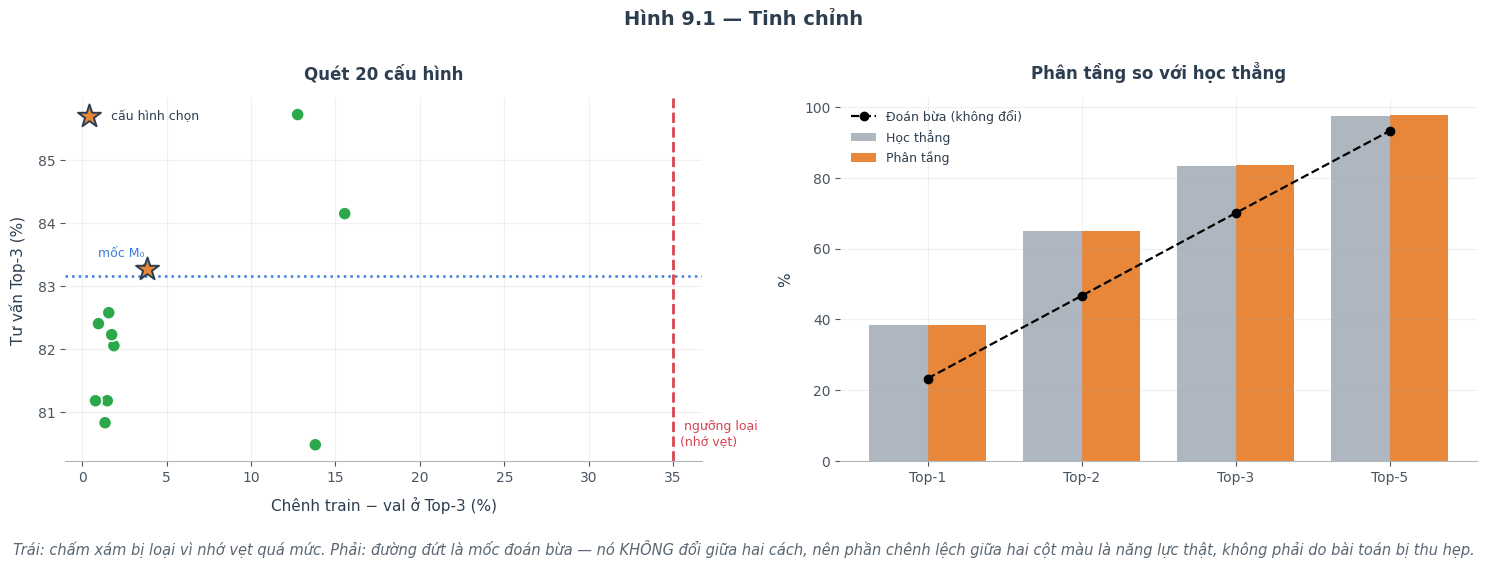

In [6]:
# ═══════════ HÌNH 9.1 — Quét siêu tham số ═══════════
fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 5.2))
a1.scatter(quet.gap_top3 * 100, quet.guided_top3 * 100, s=90,
           c=[C_GA if h else C_XAM for h in quet.hop_le],
           edgecolor="white", lw=1.2, zorder=3)
a1.axvline(GAP_TOI_DA * 100, color=C_THAT, ls="--", lw=2)
a1.text(GAP_TOI_DA * 100 + .4, quet.guided_top3.min() * 100,
        " ngưỡng loại\n(nhớ vẹt)", fontsize=9, color=C_THAT)
a1.axhline(M0["guided"]["top"]["3"] * 100, color=C_XANH, ls=":", lw=1.8)
a1.text(quet.gap_top3.min() * 100, M0["guided"]["top"]["3"] * 100 + .3,
        " mốc M₀", fontsize=9, color=C_XANH)
a1.scatter([tot.gap_top3 * 100], [tot.guided_top3 * 100], s=300, marker="*",
           c=C_CAM, edgecolor=C_DAM, lw=1.4, zorder=4, label="cấu hình chọn")
a1.set_xlabel("Chênh train − val ở Top-3 (%)"); a1.set_ylabel("Tư vấn Top-3 (%)")
a1.set_title(f"Quét {N_THU} cấu hình", fontsize=12); a1.legend(fontsize=9)

x = np.arange(len(TOP_K)); w_ = .38
a2.bar(x - w_/2, [khong_pt[f"guided_top{k}"]*100 for k in TOP_K], w_,
       color=C_XAM, label="Học thẳng")
a2.bar(x + w_/2, [co_pt[f"guided_top{k}"]*100 for k in TOP_K], w_,
       color=C_CAM, label="Phân tầng")
a2.plot(x, [bua_g[k]*100 for k in TOP_K], "k--o", lw=1.6, ms=6,
        label="Đoán bừa (không đổi)")
a2.set_xticks(x); a2.set_xticklabels([f"Top-{k}" for k in TOP_K])
a2.set_ylabel("%"); a2.set_title("Phân tầng so với học thẳng", fontsize=12)
a2.legend(fontsize=9)

fig.suptitle("Hình 9.1 — Tinh chỉnh", fontsize=14, fontweight="bold", y=1.0)
fig.tight_layout()
luu(fig, OUT, "hinh_9_1_quet.png",
    f"Trái: chấm xám bị loại vì nhớ vẹt quá mức. Phải: đường đứt là mốc đoán bừa — nó KHÔNG đổi "
    "giữa hai cách, nên phần chênh lệch giữa hai cột màu là năng lực thật, không phải do bài "
    "toán bị thu hẹp.")
plt.show()

## 5. Xác nhận trên đủ 15 fold

In [7]:
t0 = time.time()
cuoi = danh_gia(HP, w_that=W_TOT, phan_tang=PT, n_fold=len(FOLDS), dung_tc=DUNG_TC)
print(f"Xác nhận trên {len(FOLDS)} fold: {time.time()-t0:.0f}s\n")

in_bang([
    dong("Đoán bừa trong nhóm", bua_g, bua_g),
    dong("★ 3 NGÀNH PHỔ BIẾN NHẤT (không cần mô hình)", bua_pb, bua_g),
    dong("Giai đoạn 4 — M₀ (chỉ khảo sát)",
         {k: M0["guided"]["top"][str(k)] for k in TOP_K}, bua_g),
    dong("Giai đoạn 9 — sau tinh chỉnh",
         {k: cuoi[f"guided_top{k}"] for k in TOP_K}, bua_g),
], "TIẾN TRIỂN — chế độ tư vấn (validation thật, 15 fold)")
print("\nMốc PHẢI vượt là '3 ngành phổ biến nhất' — quy tắc vài dòng code, không")
print("cần khảo sát hay điểm thi. Vượt 'đoán bừa' là chưa đủ để mô hình có giá trị.")
print(f"\nMô hình hơn mốc phổ biến: "
      + " · ".join(f"Top-{k} {(cuoi[f'guided_top{k}']-bua_pb[k])*100:+.1f}đ" for k in TOP_K))
in_bang([dong("Khám phá — sau tinh chỉnh",
              {k: cuoi[f"auto_top{k}"] for k in TOP_K}, bua_a)], "CHẾ ĐỘ KHÁM PHÁ")

print(f"\nCHÊNH TRAIN − VAL ở Top-3")
print(f"   Giai đoạn 4 (M₀)   {M0['gap_train_val']['guided']['3']*100:+5.1f} điểm")
print(f"   Giai đoạn 9        {cuoi['gap_top3']*100:+5.1f} điểm")
print(f"   → train {cuoi['train_guided_top3']:.1%} · val {cuoi['guided_top3']:.1%}")

cd = pd.DataFrame([{"ma_khoi": g_, "khoi": D["ten_nhom"][g_],
                    "n_nganh": int(co_nhom[g_]), "top3": v,
                    "bua3": min(3, co_nhom[g_]) / co_nhom[g_],
                    "phan_tang": g_ in (PT or {})}
                   for g_, v in theo_khoi(cuoi).items()])
cd["hon"] = cd.top3 - cd.bua3
cd = cd.sort_values("n_nganh", ascending=False)
cd.to_csv(OUT / "chan_doan_theo_khoi.csv", index=False)

(OUT / "sieu_tham_so.json").write_text(json.dumps({
    "dung_tang_cuong": bool(DUNG_TC), "loi_ich_tang_cuong": ch,
    "hp": HP, "w_that": W_TOT, "rieng_nhom": True,
    "phan_tang": {str(g): {str(m): int(s) for m, s in b.items()}
                  for g, b in (PT or {}).items()},
    "loi_ich_phan_tang": float(co_pt["guided_top3"] - khong_pt["guided_top3"]),
    "gap_toi_da": GAP_TOI_DA, "train_toi_da": TRAIN_TOI_DA,
    "ket_qua_cv": {k: v for k, v in cuoi.items()
                   if not k.startswith(("S_", "y_"))},
    "bua_pho_bien": bua_pb,
    "hon_pho_bien": {k: cuoi[f"guided_top{k}"] - bua_pb[k] for k in TOP_K},
    "theo_khoi": cd.to_dict("records"),
}, ensure_ascii=False, indent=2, default=float), encoding="utf-8")

Xác nhận trên 15 fold: 215s

═════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
TIẾN TRIỂN — chế độ tư vấn (validation thật, 15 fold)
═════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
Cấu hình                                          Top-1     bừa     hơn  kỹ năng     Top-2     bừa     hơn  kỹ năng     Top-3     bừa     hơn  kỹ năng     Top-5     bừa     hơn  kỹ năng
─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Đoán bừa trong nhóm                              23.3%   23.3%    +0.0đ     0.0%    46.7%   46.7%    +0.0đ     0.0%    70.0%   70.0%    +0.0đ     0.0%    93.1%   93.1%    +0

3409

   💾 hinh_9_2_chan_doan.png


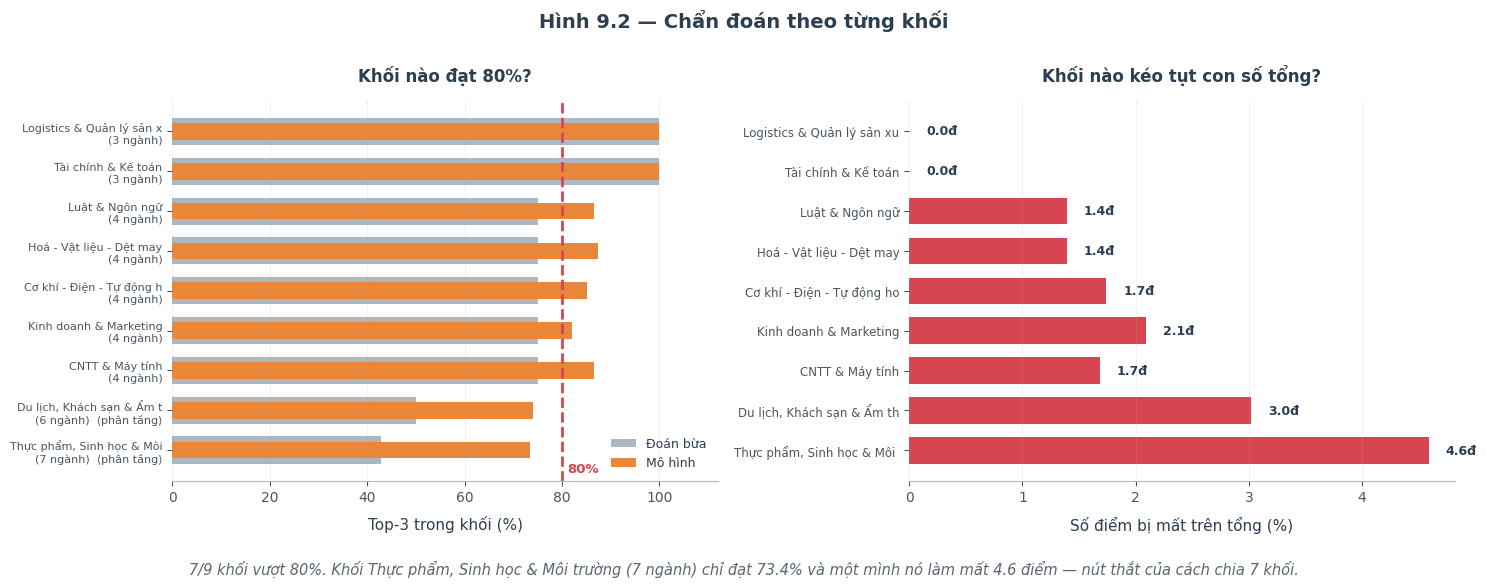

In [8]:
# ═══════════ HÌNH 9.2 — Chẩn đoán theo khối ═══════════
fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 5.4))
yy = np.arange(len(cd))
a1.barh(yy, cd.bua3 * 100, color=C_XAM, height=.68, label="Đoán bừa")
a1.barh(yy, cd.top3 * 100, color=C_CAM, height=.42, label="Mô hình")
a1.axvline(80, color=C_THAT, ls="--", lw=2)
a1.text(81, -.55, "80%", fontsize=9.5, color=C_THAT, fontweight="bold")
a1.set_yticks(yy)
a1.set_yticklabels([f"{r.khoi[:25]}\n({r.n_nganh} ngành)"
                    + ("  ⟨phân tầng⟩" if r.phan_tang else "")
                    for r in cd.itertuples()], fontsize=8)
a1.set_xlabel("Top-3 trong khối (%)"); a1.set_xlim(0, 112)
a1.set_title("Khối nào đạt 80%?", fontsize=12)
a1.legend(loc="lower right", fontsize=9); a1.grid(axis="y", alpha=0)

mat = (1 - cd.top3.values) * np.array(
    [float((nhom_sv == g_).mean()) for g_ in cd.ma_khoi]) * 100
a2.barh(yy, mat, color=C_THAT, height=.66)
a2.set_yticks(yy); a2.set_yticklabels([r.khoi[:26] for r in cd.itertuples()],
                                      fontsize=8.5)
a2.set_xlabel("Số điểm bị mất trên tổng (%)")
a2.set_title("Khối nào kéo tụt con số tổng?", fontsize=12); a2.grid(axis="y", alpha=0)
for i, v in enumerate(mat):
    a2.text(v + .15, i, f"{v:.1f}đ", va="center", fontsize=9, fontweight="bold")

fig.suptitle("Hình 9.2 — Chẩn đoán theo từng khối", fontsize=14, fontweight="bold", y=1.0)
fig.tight_layout()
xau = cd.iloc[int(np.argmax(mat))]
luu(fig, OUT, "hinh_9_2_chan_doan.png",
    f"{int((cd.top3 >= .8).sum())}/{len(cd)} khối vượt 80%. Khối {xau.khoi} "
    f"({xau.n_nganh} ngành) chỉ đạt {xau.top3:.1%} và một mình nó làm mất "
    f"{max(mat):.1f} điểm — nút thắt của cách chia 7 khối.")
plt.show()

   💾 hinh_9_3_train_val.png


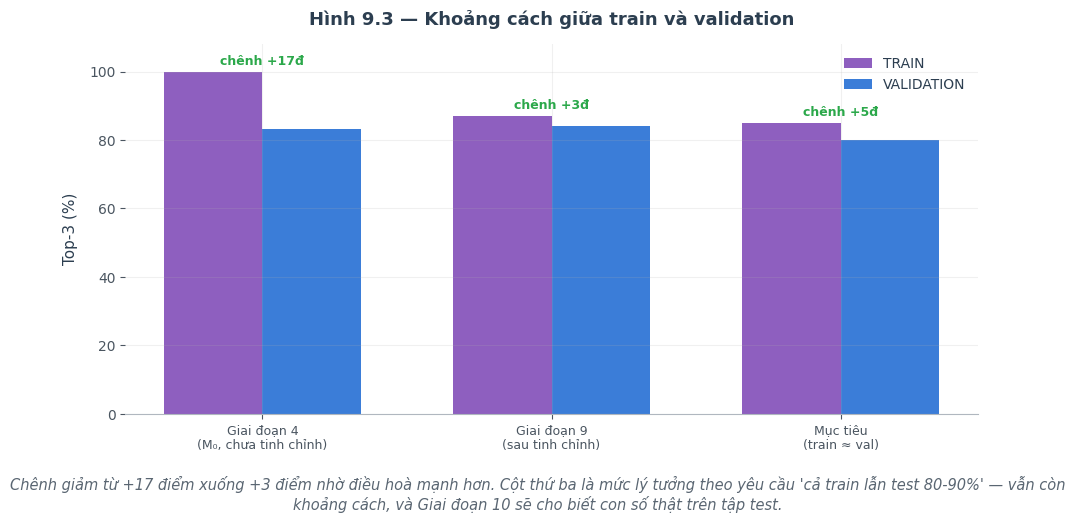

╔════════════════════════════════════════════════════════════════════════════╗
║                          GIAI ĐOẠN 9 — TINH CHỈNH                          ║
╠════════════════════════════════════════════════════════════════════════════╣
║ Đã thử                 20 cấu hình siêu tham số                            ║
║ Loại vì nhớ vẹt        15/20  (chênh > 35%)                                ║
║                                                                            ║
║ Dữ liệu tăng cường     KHÔNG   (Top-3 -0.7đ)                               ║
║ Trọng số dòng thật     ×4                                                  ║
║ Phân tầng              DÙNG cho khối 7, 4   (+0.3đ)                        ║
║                                                                            ║
║ Tư vấn Top-3           84.1%   (M₀ 83.2%, +0.9đ)                           ║
║ Tư vấn Top-5           97.6%                                               ║
║ Khám phá Top-3         27.7%                      

In [9]:
# ═══════════ HÌNH 9.3 — Train so với val ═══════════
fig, ax = plt.subplots(figsize=(11, 4.8))
x = np.arange(3); w_ = .34
nhan = ["Giai đoạn 4\n(M₀, chưa tinh chỉnh)", "Giai đoạn 9\n(sau tinh chỉnh)",
        "Mục tiêu\n(train ≈ val)"]
tr_ = [M0["guided"]["tren_train"]["3"] * 100, cuoi["train_guided_top3"] * 100, 85]
va_ = [M0["guided"]["top"]["3"] * 100, cuoi["guided_top3"] * 100, 80]
ax.bar(x - w_/2, tr_, w_, color=C_TIM, label="TRAIN")
ax.bar(x + w_/2, va_, w_, color=C_XANH, label="VALIDATION")
ax.set_xticks(x); ax.set_xticklabels(nhan, fontsize=9)
ax.set_ylabel("Top-3 (%)"); ax.set_ylim(0, 108)
ax.set_title("Hình 9.3 — Khoảng cách giữa train và validation")
ax.legend()
for i in range(3):
    ax.text(i, max(tr_[i], va_[i]) + 2, f"chênh {tr_[i]-va_[i]:+.0f}đ",
            ha="center", fontsize=9, fontweight="bold",
            color=C_THAT if tr_[i] - va_[i] > 25 else C_GA)
luu(fig, OUT, "hinh_9_3_train_val.png",
    f"Chênh giảm từ {M0['gap_train_val']['guided']['3']*100:+.0f} điểm xuống "
    f"{cuoi['gap_top3']*100:+.0f} điểm nhờ điều hoà mạnh hơn. Cột thứ ba là mức lý tưởng theo "
    "yêu cầu 'cả train lẫn test 80-90%' — vẫn còn khoảng cách, và Giai đoạn 10 sẽ cho biết con "
    "số thật trên tập test.")
plt.show()

tom_tat("GIAI ĐOẠN 9 — TINH CHỈNH", [
    f"Đã thử                 {N_THU} cấu hình siêu tham số",
    f"Loại vì nhớ vẹt        {len(quet)-len(hl)}/{len(quet)}"
    f"  (chênh > {GAP_TOI_DA:.0%})",
    "",
    f"Dữ liệu tăng cường     {'DÙNG' if DUNG_TC else 'KHÔNG'}"
    f"   (Top-3 {ch[3]*100:+.1f}đ)",
    f"Trọng số dòng thật     ×{W_TOT:.0f}",
    f"Phân tầng              {'DÙNG cho khối ' + ', '.join(str(g) for g in PT) if PT else 'KHÔNG'}"
    f"   ({(co_pt['guided_top3']-khong_pt['guided_top3'])*100:+.1f}đ)",
    "",
    f"Tư vấn Top-3           {cuoi['guided_top3']:.1%}"
    f"   (M₀ {M0['guided']['top']['3']:.1%},"
    f" {(cuoi['guided_top3']-M0['guided']['top']['3'])*100:+.1f}đ)",
    f"Tư vấn Top-5           {cuoi['guided_top5']:.1%}",
    f"Khám phá Top-3         {cuoi['auto_top3']:.1%}",
    "",
    f"Chênh train − val      {cuoi['gap_top3']*100:+.1f}đ"
    f"   (M₀ {M0['gap_train_val']['guided']['3']*100:+.1f}đ)",
    f"Khối đạt 80%           {int((cd.top3 >= .8).sum())}/{len(cd)}",
])
print(f"\n✅ sieu_tham_so.json · ket_qua_quet.csv · chan_doan_theo_khoi.csv"
      f" · 3 hình  →  {OUT}")